#Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

In [2]:
text = """
Deep learning is a branch of artificial intelligence that enables computers to learn from data.
Neural networks are inspired by the human brain and are capable of solving complex problems.
Recurrent neural networks are mainly used for sequential data such as text and speech.
LSTM is an improved version of RNN that remembers long-term information.
GRU is another advanced recurrent network that is faster and simpler than LSTM.
Text generation is one of the important applications of deep learning.
Deep learning models are widely used in machine translation, chatbots, and speech recognition.
Artificial intelligence is transforming healthcare, education, finance, and many other industries.
"""

#Tokenization

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 72


In [4]:
input_sequences = []

for line in text.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

In [5]:
max_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_len,
        padding='pre'
    )
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (96, 14)
Output Shape: (96,)


#Vanilla RNN Model

In [6]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    )
)

rnn_model.add(
    SimpleRNN(128)
)

rnn_model.add(
    Dense(total_words, activation='softmax')
)

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_rnn = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0312 - loss: 4.2752
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1146 - loss: 4.1471
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1250 - loss: 4.0532
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1146 - loss: 3.9946
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1562 - loss: 3.9143
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2083 - loss: 3.8518
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2812 - loss: 3.7481
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2604 - loss: 3.6583
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2604 - loss: 3.5598
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2708 - loss: 3.4570
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3542 - loss: 3.3439
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3542 - lo

#Build LSTM Model

In [8]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    )
)

lstm_model.add(
    LSTM(128)
)

lstm_model.add(
    Dense(total_words, activation='softmax')
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_lstm = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.0104 - loss: 4.2782  
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0521 - loss: 4.2666
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0833 - loss: 4.2525
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0833 - loss: 4.2335
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0625 - loss: 4.1874
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0625 - loss: 4.0913
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0625 - loss: 4.0495
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0625 - loss: 4.0214
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0833 - loss: 3.9736
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1146 - loss: 3.9524
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1146 - loss: 3.9046
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0938 - 

#GRU Model

In [10]:
gru_model = Sequential()

gru_model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    )
)

gru_model.add(
    GRU(128)
)

gru_model.add(
    Dense(total_words, activation='softmax')
)

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_gru = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.0208 - loss: 4.2778
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1250 - loss: 4.2614
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1667 - loss: 4.2477
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1458 - loss: 4.2302
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1562 - loss: 4.2098
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1250 - loss: 4.1786
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1042 - loss: 4.1199
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0833 - loss: 4.0369
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0625 - loss: 3.9874
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0729 - loss: 3.9487
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0833 - loss: 3.9123
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1042 - lo

#Compare Training Loss

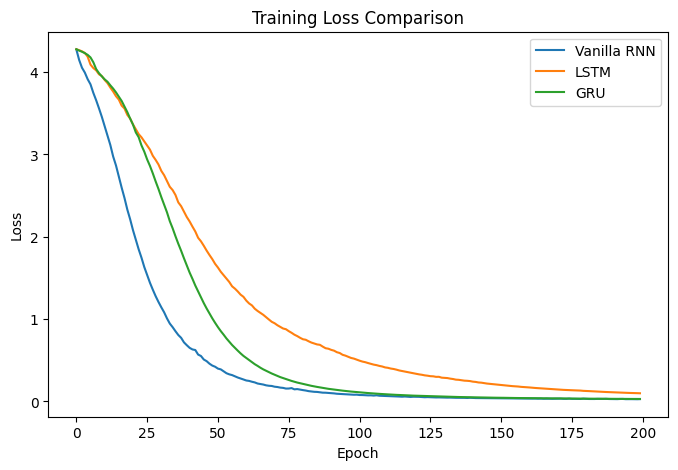

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Vanilla RNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()

plt.show()

#Text Generation Function

In [13]:
def generate_text(model, seed_text, next_words):

    for i in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0)
        )

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

#Generate Text (10 Words)

In [14]:
print("Generated using Vanilla RNN:")
print(generate_text(rnn_model, "deep learning", 10))

print()

print("Generated using LSTM:")
print(generate_text(lstm_model, "deep learning", 10))

print()

print("Generated using GRU:")
print(generate_text(gru_model, "deep learning", 10))

Generated using Vanilla RNN:
deep learning is a branch of artificial intelligence that enables computers to

Generated using LSTM:
deep learning is a branch of artificial intelligence that enables computers to

Generated using GRU:
deep learning is a branch of artificial intelligence that enables computers to


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**